In [1]:
# Cell 1 — imports
import pandas as pd
import numpy as np
import lightgbm as lgb
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, roc_auc_score,
                               confusion_matrix, roc_curve)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

In [2]:
# Cell 2 — build model function (reused for both datasets)
def build_churn_model(filepath, target_col, model_name):
    df = pd.read_csv(filepath)
    # Drop target AND any binary-encoded version of it
    cols_to_drop = [target_col, 'Churn_binary', 'Attrition_binary']
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    X = df.drop(cols_to_drop, axis=1)
    y = df[target_col]

    print(f"\n=== {model_name} ===")
    print(f"Class balance: {y.value_counts().to_dict()}")
    print(f"Churn/attrition rate: {y.mean()*100:.1f}%")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    # Handle imbalance with SMOTE
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
    print(f"After SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")

    # Train LightGBM
    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    )
    model.fit(X_train_sm, y_train_sm,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(50, verbose=False)])

    # Evaluate
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {model_name}'); plt.legend(); plt.show()
    
    # Save model and test data
    joblib.dump(model, f'../models/{model_name}.pkl')
    X_test['actual'] = y_test.values
    X_test['predicted'] = y_pred
    X_test['churn_probability'] = y_prob
    X_test.to_csv(f'../data/processed/{model_name}_predictions.csv', index=False)

    return model, X_test, X_train_sm, y_train_sm


=== customer_churn_lgbm ===
Class balance: {0: 5174, 1: 1869}
Churn/attrition rate: 26.5%
After SMOTE: {0: 4139, 1: 4139}

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.59      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

ROC-AUC: 0.8422


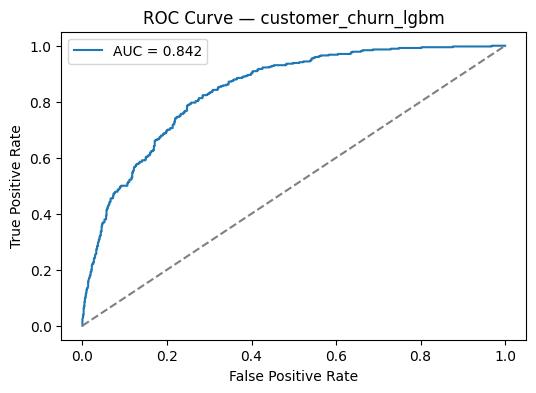

In [3]:
# Cell 3 — run for customer churn
cust_model, cust_test, cust_Xtrain, cust_ytrain = build_churn_model(
    '../data/processed/customer_churn_clean.csv',
    'Churn', 'customer_churn_lgbm')


=== employee_churn_lgbm ===
Class balance: {0: 1233, 1: 237}
Churn/attrition rate: 16.1%
After SMOTE: {0: 986, 1: 986}

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.58      0.30      0.39        47

    accuracy                           0.85       294
   macro avg       0.73      0.63      0.66       294
weighted avg       0.83      0.85      0.83       294

ROC-AUC: 0.7995


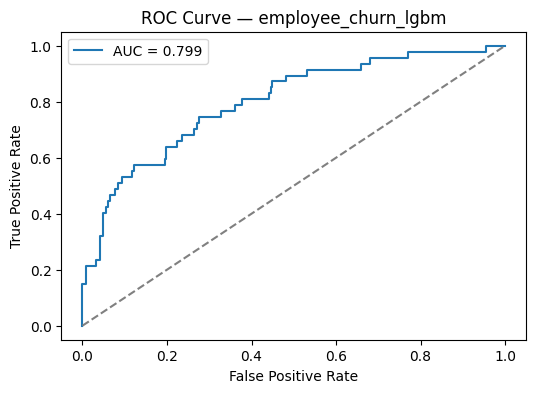

In [4]:
# Cell 4 — run for employee attrition
emp_model, emp_test, emp_Xtrain, emp_ytrain = build_churn_model(
    '../data/processed/employee_attrition_clean.csv',
    'Attrition', 'employee_churn_lgbm')